# pennylaneのコード例
[リンク](https://pennylane.ai/qml/demos/tutorial_apply_qsvt/)

In [1]:
import pennylane as qml
from pennylane import numpy as np

dev = qml.device("lightning.qubit", wires=[0, 1])

A = np.array([[0.1, 0.2], [0.3, 0.4]])
phase_angles = np.array([0.0, 1.0, 2.0, 3.0])

block_encoding = qml.BlockEncode(A, wires=[0, 1])
projectors = [qml.PCPhase(angle, dim=2, wires=[0, 1]) for angle in phase_angles]


@qml.qnode(dev)
def my_circuit():
    qml.QSVT(block_encoding, projectors)
    return qml.state()

In [2]:
my_circuit()
print(qml.draw(my_circuit, level = "top")())

0: ─╭QSVT─┤  State
1: ─╰QSVT─┤  State


In [3]:
print(qml.draw(my_circuit)())

0: ─╭∏_ϕ(0.00)─╭BlockEncode(M0)─╭∏_ϕ(1.00)─╭BlockEncode(M0)†─╭∏_ϕ(2.00)─╭BlockEncode(M0) ···
1: ─╰∏_ϕ(0.00)─╰BlockEncode(M0)─╰∏_ϕ(1.00)─╰BlockEncode(M0)†─╰∏_ϕ(2.00)─╰BlockEncode(M0) ···

0: ··· ─╭∏_ϕ(3.00)─┤  State
1: ··· ─╰∏_ϕ(3.00)─┤  State

M0 = 
[[0.1 0.2]
 [0.3 0.4]]


In [ ]:
# NOTE: 以下で2種類のqsvt回路の合成をしており、片方はコメントアウト
# kappa = 4
# s = 0.10145775
# phi_pyqsp = [-2.287, 2.776, -1.163, 0.408, -0.16, -0.387, 0.385, -0.726, 0.456, 0.062, -0.468, 0.393, 0.028, -0.567, 0.76, -0.432, -0.011, 0.323, -0.573, 0.82, -1.096, 1.407, -1.735, 2.046, -2.321, 2.569, -2.819, -0.011, 2.71, -2.382, 2.574, 0.028, -2.749, 2.673, 0.062, -2.685, 2.416, 0.385, -0.387, -0.16, 0.408, -1.163, -0.365, 2.426]
# phi_qsvt = qml.transform_angles(phi_pyqsp, "QSP", "QSVT")  # convert pyqsp angles to be compatible with QSVT

In [5]:
# x_vals = np.linspace(0, 1, 50)
# target_y_vals = [s * (1 / x) for x in np.linspace(s, 1, 50)]

# qsvt_y_vals = []
# for x in x_vals:

#     block_encoding = qml.BlockEncode(x, wires=[0])
#     projectors = [qml.PCPhase(angle, dim=1, wires=[0]) for angle in phi_qsvt]

#     poly_x = qml.matrix(qml.QSVT, wire_order=[0])(block_encoding, projectors)
#     qsvt_y_vals.append(np.real(poly_x[0, 0]))

In [6]:
import matplotlib.pyplot as plt

# plt.plot(x_vals, np.array(qsvt_y_vals), label="Re(qsvt)")
# plt.plot(np.linspace(s, 1, 50), target_y_vals, label="target")

# plt.vlines(1 / kappa, -1.0, 1.0, linestyle="--", color="grey", label="1/kappa")
# plt.vlines(0.0, -1.0, 1.0, color="black")
# plt.hlines(0.0, -0.1, 1.0, color="black")

# plt.legend()
# plt.show()

In [7]:
def sum_even_odd_circ(x, phi, ancilla_wire, wires):
    phi1, phi2 = phi[: len(phi) // 2], phi[len(phi) // 2 :]
    block_encode = qml.BlockEncode(x, wires=wires)

    qml.Hadamard(wires=ancilla_wire)  # equal superposition

    # apply even and odd polynomial approx

    dim = x.shape[0] if x.ndim > 0 else 1
    projectors_even = [qml.PCPhase(angle, dim= dim, wires=wires) for angle in phi1]
    qml.ctrl(qml.QSVT, control=(ancilla_wire,), control_values=(0,))(block_encode, projectors_even)

    projectors_odd = [qml.PCPhase(angle, dim= dim, wires=wires) for angle in phi2]
    qml.ctrl(qml.QSVT, control=(ancilla_wire,), control_values=(0,))(block_encode, projectors_odd)

    qml.Hadamard(wires=ancilla_wire)  # un-prepare superposition

In [8]:
np.random.seed(42)  # set seed for reproducibility
phi = np.random.rand(51)

In [9]:
kappa = 4
s = 0.10145775

samples_x = np.linspace(1 / kappa, 1, 100)

def target_func(x):
    return s * (1 / x)

def loss_func(phi):
    sum_square_error = 0
    for x in samples_x:
        qsvt_matrix = qml.matrix(sum_even_odd_circ, wire_order=["ancilla", 0])(x, phi, ancilla_wire="ancilla", wires=[0])
        qsvt_val = qsvt_matrix[0, 0]
        sum_square_error += (np.real(qsvt_val) - target_func(x)) ** 2

    return sum_square_error / len(samples_x)

In [10]:
# Optimization:
cost = 1
iter = 0
opt = qml.AdagradOptimizer(0.1)

while cost > 0.5e-4:
    iter += 1
    phi, cost = opt.step_and_cost(loss_func, phi)

    if iter % 10 == 0 or iter == 1:
        print(f"iter: {iter}, cost: {cost}")

    if iter > 100:
        print("Iteration limit reached!")
        break

print(f"Completed Optimization! (final cost: {cost})")
print(f"final phi: {phi}")

iter: 1, cost: 0.15857732565208663
iter: 10, cost: 0.003103479152864891
iter: 20, cost: 0.0006778138155746395
iter: 30, cost: 0.00031460744228923383
iter: 40, cost: 0.00023048920828044515
iter: 50, cost: 0.00019430503819374366
iter: 60, cost: 0.00017113323304668822
iter: 70, cost: 0.00015372692374648496
iter: 80, cost: 0.00013985612914810863
iter: 90, cost: 0.0001285371396971184
iter: 100, cost: 0.0001192499832559535
Iteration limit reached!
Completed Optimization! (final cost: 0.00011841016400720652)
final phi: [ 0.45455227  0.84696948  0.5569736   0.64430073  0.05581771  0.19765715
 -0.02467683  0.90828275  0.35507036  0.68143761  0.05821724  0.93990246
  0.9239721   0.21680908  0.28988894  0.18541656  0.38969463  0.56661724
  0.42635437  0.38567509  0.56660555  0.17608483  0.28708074  0.35889656
  0.51632033  0.8454263   0.08488017  0.56828315  0.48360304  0.11040298
  0.48515582  0.30655631 -0.07170676  1.08228206  0.78399662  0.57251039
  0.3789384  -0.05721427  0.76666548  0.5715

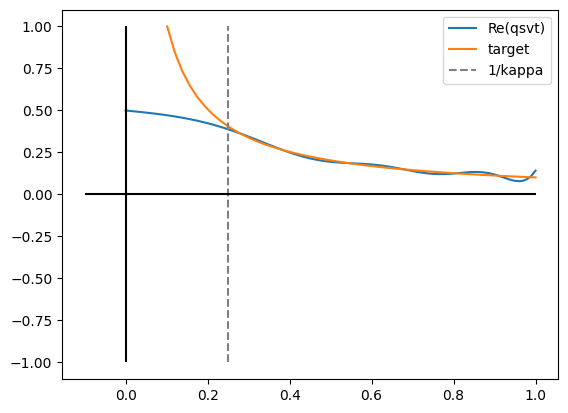

In [11]:
samples_inv = np.linspace(s, 1, 50)
inv_x = [target_func(x) for x in samples_inv]

samples_x = np.linspace(0, 1, 100)
qsvt_y_vals = [
    np.real(qml.matrix(sum_even_odd_circ, wire_order=["ancilla", 0])(x, phi, "ancilla", wires=[0])[0, 0])
    for x in samples_x
]

plt.plot(samples_x, qsvt_y_vals, label="Re(qsvt)")
plt.plot(samples_inv, inv_x, label="target")

plt.vlines(1 / kappa, -1.0, 1.0, linestyle="--", color="grey", label="1/kappa")
plt.vlines(0.0, -1.0, 1.0, color="black")
plt.hlines(0.0, -0.1, 1.0, color="black")

plt.legend()
plt.show()

In [12]:
def real_u(A, phi):
    qml.Hadamard(wires="ancilla1")

    qml.ctrl(sum_even_odd_circ, control=("ancilla1",), control_values=(0,))(A, phi, "ancilla2", [0, 1, 2])
    qml.ctrl(qml.adjoint(sum_even_odd_circ), control=("ancilla1",), control_values=(1,))(A.T, phi, "ancilla2", [0, 1, 2])

    qml.Hadamard(wires="ancilla1")

In [13]:
A = np.array(
    [
        [0.65713691, -0.05349524, 0.08024556, -0.07242864],
        [-0.05349524, 0.65713691, -0.07242864, 0.08024556],
        [0.08024556, -0.07242864, 0.65713691, -0.05349524],
        [-0.07242864, 0.08024556, -0.05349524, 0.65713691],
    ]
)

b = np.array([1, 2, 3, 4], dtype="complex")
target_x = np.linalg.inv(A) @ b  # true solution

# Normalize states:
norm_b = np.linalg.norm(b)
normalized_b = b / norm_b

norm_x = np.linalg.norm(target_x)
normalized_x = target_x / norm_x

In [14]:
@qml.qnode(qml.device("default.qubit", wires=["ancilla1", "ancilla2", 0, 1, 2]))
def linear_system_solver_circuit(phi):
    qml.StatePrep(normalized_b, wires=[1, 2])
    real_u(A.T, phi)  # invert the singular values of A transpose to get A^-1
    return qml.state()


print("phi:", phi)
transformed_state = linear_system_solver_circuit(phi)[:4]  # first 4 entries of the state
rescaled_computed_x = transformed_state * norm_b / s
normalized_computed_x = rescaled_computed_x / np.linalg.norm(rescaled_computed_x)

print("target x:", np.round(normalized_x, 3))
print("computed x:", np.round(normalized_computed_x, 3))

phi: [ 0.45455227  0.84696948  0.5569736   0.64430073  0.05581771  0.19765715
 -0.02467683  0.90828275  0.35507036  0.68143761  0.05821724  0.93990246
  0.9239721   0.21680908  0.28988894  0.18541656  0.38969463  0.56661724
  0.42635437  0.38567509  0.56660555  0.17608483  0.28708074  0.35889656
  0.51632033  0.8454263   0.08488017  0.56828315  0.48360304  0.11040298
  0.48515582  0.30655631 -0.07170676  1.08228206  0.78399662  0.57251039
  0.3789384  -0.05721427  0.76666548  0.57159184 -0.11201734  0.64827136
 -0.18795938  1.0553686   0.18714317  0.55571658  0.40664414  0.33668126
  0.65239319  0.29666154  1.04959678]
target x: [0.205+0.j 0.335+0.j 0.582+0.j 0.712+0.j]
computed x: [0.202-0.j 0.341+0.j 0.576-0.j 0.715-0.j]
